Using device: cuda
Total files found: 7442
Classes: [0 1 2 3 4 5]
Train: 4421, Val: 1475, Test: 1546
Pre-loading audio files into memory...
Loading 0/4421...
Loading 500/4421...
Loading 1000/4421...
Loading 1500/4421...
Loading 2000/4421...
Loading 2500/4421...
Loading 3000/4421...
Loading 3500/4421...
Loading 4000/4421...
Loading 0/1475...
Loading 500/1475...
Loading 1000/1475...
Loading 0/1546...
Loading 500/1546...
Loading 1000/1546...
Loading 1500/1546...
Audio pre-loading complete.


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Final Evaluation on Test Set ---


Test Accuracy: 70.96%
Test F1 Score: 70.80%

Test Macro AUC: 0.9010
Per-class AUC:
  0: 0.9327
  1: 0.8360
  2: 0.9079
  3: 0.9183
  4: 0.9539
  5: 0.8570


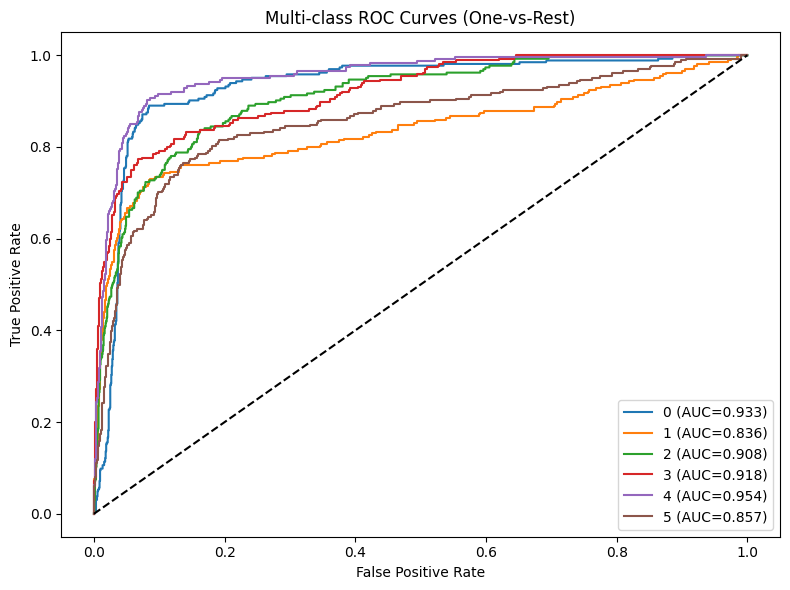

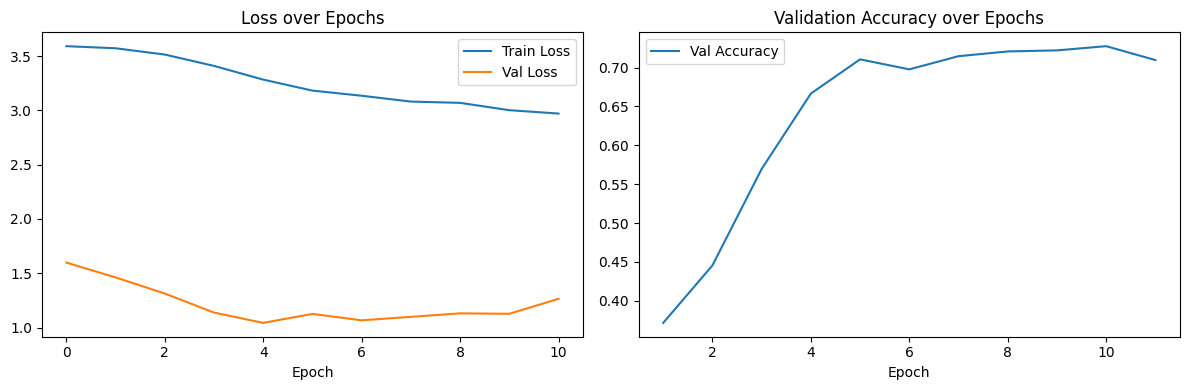

              precision    recall  f1-score   support

           0       0.60      0.89      0.72       264
           1       0.78      0.61      0.68       264
           2       0.72      0.65      0.68       264
           3       0.78      0.72      0.75       264
           4       0.77      0.80      0.78       226
           5       0.68      0.61      0.64       264

    accuracy                           0.71      1546
   macro avg       0.72      0.71      0.71      1546
weighted avg       0.72      0.71      0.71      1546



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to 'wav2vec2_ser_final'


In [2]:
# %% [markdown]
# ### Fine‑tune Wav2Vec2 for Speech Emotion Recognition (with ROC curves and training plots)

# %%
!pip install transformers datasets librosa soundfile accelerate scikit-learn matplotlib -q

# %%
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    Wav2Vec2ForSequenceClassification,
    Wav2Vec2Processor,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_curve, roc_auc_score
import librosa
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Disable distributed training to avoid DistNetworkError on single-node clusters
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['RANK'] = '-1'
os.environ['LOCAL_RANK'] = '-1'

# %% [markdown]
# ### 1. Configuration

# %%
class Wav2Vec2Config:
    # Model
    model_name = "facebook/wav2vec2-base"      # use "facebook/wav2vec2-large-xlsr-53" for higher accuracy
    num_classes = 6

    # Training
    batch_size = 8
    max_grad_norm = 1.0        # 🔑 GRADIENT CLIPPING ADDED HERE
    early_stopping_patience = 4 # Reduced patience to stop faster on overfi
    learning_rate = 2e-5
    weight_decay = 0.01
    num_epochs = 10
    warmup_ratio = 0.2
    gradient_accumulation_steps = 2
    max_length = 16000 * 5                      # 5 seconds at 16 kHz

    # Paths – adjust to your dataset location
    data_root = "/content"
    model_save_path = "/content/wav2vec2_ser_model"

# %% [markdown]
# ### 2. Load Dataset (same as before)

# %%
def load_cremad_dataset(data_root):
    emotion_map = {'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}
    file_paths, emotions, speakers = [], [], []
    audio_dir = os.path.join(data_root, 'AudioWAV')
    if not os.path.isdir(audio_dir):
        raise ValueError(f"AudioWAV directory not found at {audio_dir}")
    for fname in os.listdir(audio_dir):
        if fname.lower().endswith('.wav'):
            parts = fname.split('_')
            if len(parts) >= 3:
                speaker_id = parts[0]
                emotion_code = parts[2].upper()
                if emotion_code in emotion_map:
                    file_paths.append(os.path.join(audio_dir, fname))
                    emotions.append(emotion_map[emotion_code])
                    speakers.append(speaker_id)
    print(f"Total files found: {len(file_paths)}")
    if len(file_paths) == 0:
        raise ValueError(f"No .wav files found in {audio_dir}. Please verify the dataset path and structure.")
    return file_paths, emotions, speakers

config = Wav2Vec2Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

file_paths, emotion_ids, speakers = load_cremad_dataset(config.data_root)
le = LabelEncoder()
labels = le.fit_transform(emotion_ids)
print(f"Classes: {le.classes_}")

# Speaker‑independent split
unique_speakers = list(set(speakers))
train_speakers, temp_speakers = train_test_split(unique_speakers, test_size=0.4, random_state=42)
val_speakers, test_speakers = train_test_split(temp_speakers, test_size=0.5, random_state=42)

train_idx = [i for i, spk in enumerate(speakers) if spk in train_speakers]
val_idx   = [i for i, spk in enumerate(speakers) if spk in val_speakers]
test_idx  = [i for i, spk in enumerate(speakers) if spk in test_speakers]

X_train = [file_paths[i] for i in train_idx]
y_train = [labels[i] for i in train_idx]
X_val   = [file_paths[i] for i in val_idx]
y_val   = [labels[i] for i in val_idx]
X_test  = [file_paths[i] for i in test_idx]
y_test  = [labels[i] for i in test_idx]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# %% [markdown]
# ### 3. Pre-load Audio Data to Avoid Volume Access in Workers

# %%
print("Pre-loading audio files into memory...")

def preload_audio_data(file_paths):
    """Load all audio files into memory arrays to avoid Volume access during training."""
    audio_data = []
    for i, path in enumerate(file_paths):
        if i % 500 == 0:
            print(f"Loading {i}/{len(file_paths)}...")
        try:
            audio, sr = librosa.load(path, sr=16000)
            audio_data.append(audio)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            audio_data.append(np.zeros(16000))  # Fallback to silence if load fails
    return audio_data

train_audio = preload_audio_data(X_train)
val_audio = preload_audio_data(X_val)
test_audio = preload_audio_data(X_test)
print("Audio pre-loading complete.")

# %% [markdown]
# ### 4. Processor and Dataset

# %%
processor = Wav2Vec2Processor.from_pretrained(config.model_name)

class SERDataset(Dataset):
    def __init__(self, audio_arrays, labels, processor, max_length):
        self.audio_arrays = audio_arrays
        self.labels = labels
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.audio_arrays)

    def __getitem__(self, idx):
        audio = self.audio_arrays[idx]
        inputs = self.processor(audio, sampling_rate=16000,
                                return_tensors="pt", padding="max_length",
                                max_length=self.max_length, truncation=True)
        return {
            "input_values": inputs.input_values.squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

# %%
train_dataset = SERDataset(train_audio, y_train, processor, config.max_length)
val_dataset   = SERDataset(val_audio,   y_val,   processor, config.max_length)
test_dataset  = SERDataset(test_audio,  y_test,  processor, config.max_length)

# %% [markdown]
# ### 5. Model

# %%
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    config.model_name,
    num_labels=config.num_classes,
    ignore_mismatched_sizes=True
)
model.to(device)

# %% [markdown]
# ### 6. Custom Trainer to Collect Probabilities for ROC

# %%
class ROCTrainer(Trainer):
    """Extend Trainer to store predictions and labels for ROC after evaluation."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.test_preds = None
        self.test_labels = None

    def predict(self, test_dataset):
        """Override predict to store probabilities and labels for ROC."""
        result = super().predict(test_dataset)
        self.test_preds = result.predictions   # logits
        self.test_labels = result.label_ids
        return result

# %% [markdown]
# ### 7. Training Arguments and Trainer

# %%
training_args = TrainingArguments(
    output_dir=config.model_save_path,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=config.learning_rate,
    per_device_train_batch_size=config.batch_size,
    per_device_eval_batch_size=config.batch_size,
    gradient_accumulation_steps=config.gradient_accumulation_steps,
    weight_decay=config.weight_decay,
    num_train_epochs=config.num_epochs,
    warmup_ratio=config.warmup_ratio,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=False,
    max_grad_norm=config.max_grad_norm,   # 🔑 GRADIENT CLIPPING
    label_smoothing_factor=0.1,
    dataloader_num_workers=0,
    report_to="none"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

trainer = ROCTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=processor,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

# %% [markdown]
# ### 8. Train

# %%
trainer.train()

# %% [markdown]
# ### 9. Evaluation on Test Set with ROC Curves and Training History

# %%
print("\n--- Final Evaluation on Test Set ---")
test_results = trainer.evaluate(test_dataset)
print(f"Test Accuracy: {test_results['eval_accuracy']*100:.2f}%")
print(f"Test F1 Score: {test_results['eval_f1']*100:.2f}%")

# Get predictions and probabilities
test_preds = trainer.predict(test_dataset)
logits = test_preds.predictions
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
true_labels = test_preds.label_ids

# Macro and per‑class AUC
macro_auc = roc_auc_score(true_labels, probs, multi_class='ovr', average='macro')
per_class_auc = roc_auc_score(true_labels, probs, multi_class='ovr', average=None)
print(f"\nTest Macro AUC: {macro_auc:.4f}")
print("Per-class AUC:")
for i, auc_val in enumerate(per_class_auc):
    print(f"  {le.classes_[i]}: {auc_val:.4f}")

# Plot ROC curves
plt.figure(figsize=(8,6))
for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve([1 if label == i else 0 for label in true_labels], probs[:, i])
    plt.plot(fpr, tpr, label=f'{class_name} (AUC={per_class_auc[i]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Plot training history (loss and accuracy)
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
eval_acc = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]

epochs = range(1, len(eval_acc)+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_loss[:len(eval_acc)], label='Train Loss')
plt.plot(eval_loss, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1,2,2)
plt.plot(epochs, eval_acc, label='Val Accuracy')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

# Classification report
class_names_str = [str(c) for c in le.classes_]
print(classification_report(true_labels, np.argmax(logits, axis=1), target_names=class_names_str))

# %% [markdown]
# ### 10. Save Final Model

# %%
model.save_pretrained("wav2vec2_ser_final")
processor.save_pretrained("wav2vec2_ser_final")
print("Model saved to 'wav2vec2_ser_final'")

# %% [markdown]
# ### 11. Inference Example (optional)

# %%
def predict_emotion(audio_path):
    audio, sr = librosa.load(audio_path, sr=16000)
    inputs = processor(audio, sampling_rate=16000, return_tensors="pt", padding=True)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.nn.functional.softmax(logits, dim=-1).numpy()[0]
    pred_id = np.argmax(probs)
    return le.classes_[pred_id], probs

# Uncomment to test on a single file:
# emotion, probs = predict_emotion("path/to/audio.wav")
# print(f"Predicted emotion: {emotion}")
# print(f"Probabilities: {dict(zip(le.classes_, probs))}")